# Balmer decrement as a dust indicator in SDSS galaxies

**Date:** 2026-07-31  
**Scientific question:** What colour excess is implied by the observed H-alpha to H-beta ratio?  
**Preserved source:** `../2026-07-31-sdss-bpt-galaxy-classification/sdss_bpt_query.csv`

Hydrogen recombination predicts an intrinsic H-alpha/H-beta ratio near 2.86 for
      standard nebular conditions. Dust removes more blue H-beta light, increasing the ratio.
      We convert the observed ratio to an approximate colour excess using a commonly adopted
      optical attenuation curve and report the median with a bootstrap interval.

      Stellar absorption beneath H-beta, aperture effects, flux calibration, and different
      nebular conditions can mimic part of the change. The estimate is therefore a diagnostic,
      not a full dust model. Raising the four-line signal-to-noise threshold tests whether noisy
      denominators dominate the result.

## Analysis contract

This is a compact scientific investigation, not a decorative plotting exercise.
The input is a preserved subset of a public astronomical archive. The notebook
records the upstream table or product, explains every quality cut, prints the
sample size after filtering, reports a numerical result with uncertainty, and
changes at least one defensible analysis choice to test robustness.

Archive catalogue values are heterogeneous measurements collected from the
literature or survey pipelines. A trend in this notebook is therefore a trend
in the selected archive sample, not automatically an occurrence rate, causal
relation, or complete census of nature. Display images are treated as image
arrays rather than calibrated photometry. Spectral equivalent widths identify
relative line strength but do not become elemental abundances without an
atmosphere model.

The small CSV or image already stored in this repository is used so the checked
notebook can be rerun offline. Its provenance remains the original archive; the
local copy is not a new survey release. Random resampling uses a fixed seed so
the uncertainty check is repeatable.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scienceplots
from scipy import stats

RNG = np.random.default_rng(1999)
plt.style.use(["science", "no-latex"])
COLORS = {"navy":"#071426", "blue":"#1797c9", "cyan":"#2fc6b4",
          "gold":"#f4b942", "orange":"#ef6a45", "rose":"#ce4f78"}

In [2]:
raw=pd.read_csv("../2026-07-31-sdss-bpt-galaxy-classification/sdss_bpt_query.csv")
lines=["h_alpha","h_beta","oiii_5007","nii_6584"]
sample=raw.copy()
for line in lines: sample=sample[(sample[f"{line}_flux"]>0)&(sample[f"{line}_flux_err"]>0)]
print(f"Positive four-line measurements: {len(sample):,} of {len(raw):,}")

Positive four-line measurements: 11,952 of 12,000


In [3]:
for line in lines: sample[f"snr_{line}"]=sample[f"{line}_flux"]/sample[f"{line}_flux_err"]
clean=sample[(sample[[f"snr_{x}" for x in lines]]>=5).all(axis=1)].copy(); clean["balmer"]=clean.h_alpha_flux/clean.h_beta_flux
clean=clean[clean.balmer.between(2,12)]; kHb,kHa=3.61,2.53; clean["ebv"]=2.5/(kHb-kHa)*np.log10(clean.balmer/2.86)
median=float(clean.ebv.median()); boot=[clean.ebv.sample(len(clean),replace=True,random_state=i).median() for i in range(500)]; lo,hi=np.percentile(boot,[16,84])
print(f"N={len(clean):,}; median E(B-V)={median:.3f}; 68% {lo:.3f}–{hi:.3f}")

N=11,898; median E(B-V)=0.327; 68% 0.325–0.329


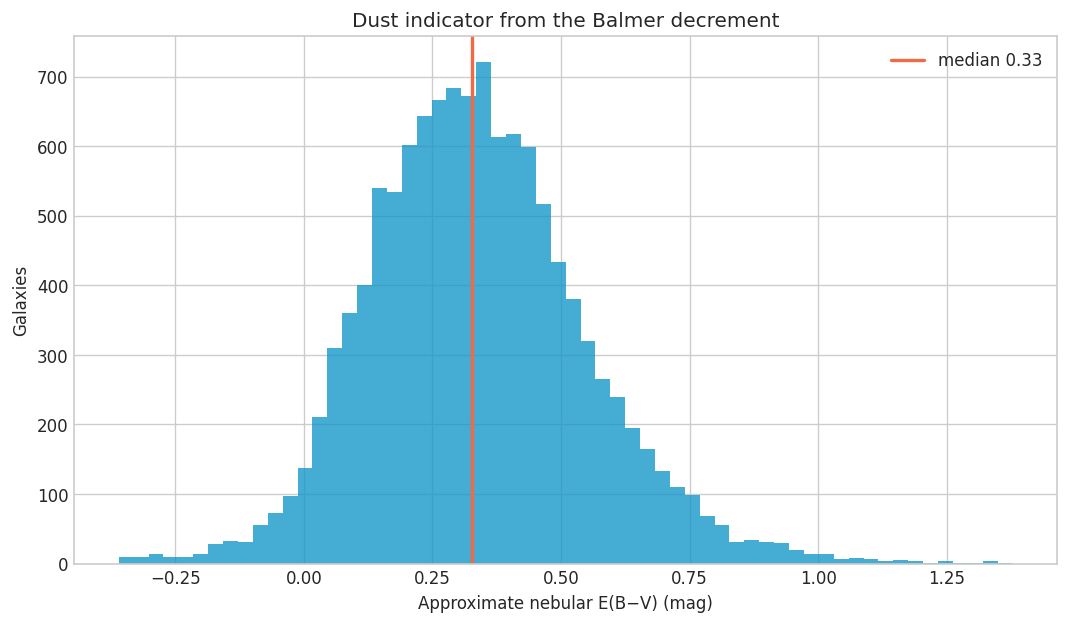

In [4]:
fig,ax=plt.subplots(figsize=(9,5.3)); ax.hist(clean.ebv,bins=60,color=COLORS["blue"],alpha=.8); ax.axvline(median,color=COLORS["orange"],lw=2,label=f"median {median:.2f}"); ax.set(xlabel="Approximate nebular E(B−V) (mag)",ylabel="Galaxies",title="Dust indicator from the Balmer decrement"); ax.legend(); fig.tight_layout(); fig.savefig("balmer_decrement_dust.png",dpi=180); plt.show()

In [5]:
strict=sample[(sample[[f"snr_{x}" for x in lines]]>=8).all(axis=1)].copy(); strict["balmer"]=strict.h_alpha_flux/strict.h_beta_flux; strict=strict[strict.balmer.between(2,12)]; strict["ebv"]=2.5/(kHb-kHa)*np.log10(strict.balmer/2.86); strict_med=float(strict.ebv.median()); print(f"S/N≥8 median={strict_med:.3f} (N={len(strict):,})")

S/N≥8 median=0.297 (N=7,745)


In [6]:
result={"id":"2026-07-31-balmer-decrement-dust","title":"SDSS Balmer-decrement dust indicator","archive":"SDSS","date":"2026-07-31","question":"What colour excess is implied by Hα/Hβ?","sample_size":int(len(clean)),"results":[f"median E(B−V) {median:.3f} mag",f"bootstrap 68% {lo:.3f}–{hi:.3f} mag",f"S/N≥8 median {strict_med:.3f} mag"],"validation":"The median is repeated with every emission line required at S/N≥8.","notebook":"sdss/2026-07-31-balmer-decrement-dust/notebook.ipynb","hero":"sdss/2026-07-31-balmer-decrement-dust/balmer_decrement_dust.png","tags":["Balmer decrement","dust","emission lines"]}; Path("result.json").write_text(json.dumps(result,indent=2)); print(result["results"])

['median E(B−V) 0.327 mag', 'bootstrap 68% 0.325–0.329 mag', 'S/N≥8 median 0.297 mag']


## Reading the result responsibly

The primary number answers the stated question only for the documented sample
and method. The stress test asks whether a reasonable threshold change reverses
the conclusion. Agreement does not remove shared selection effects, calibration
limits, unresolved multiplicity, or missing catalogue fields. Disagreement is
reported rather than hidden. A publishable follow-up would repeat the query
against a pinned archive release, model the survey selection function, and use
the original calibrated products where available.

The notebook deliberately separates observation, calculation, interpretation,
and limitation. That makes it useful as a learning record and makes each claim
easy for another reader to audit.

Numerical precision in the printed summary follows the scale supported by this
exercise; extra decimal places would not create extra physical accuracy. The
saved figure exposes the distribution behind the headline value, while the
machine-readable result file lets the dashboard report the finding without
scraping prose. Readers should inspect the executed cells before reusing any
number in a wider scientific argument.

## Sources and comparison literature

- SDSS data access and acknowledgement: https://www.sdss.org/science/
- Kewley et al. (2001), theoretical extreme-starburst boundary: https://arxiv.org/abs/astro-ph/0106324
- Kauffmann et al. (2003), empirical BPT separation: https://arxiv.org/abs/astro-ph/0304239
- Pettini & Pagel (2004), N2 and O3N2 abundance indicators: https://arxiv.org/abs/astro-ph/0401128

Strong-line calibrations carry systematic differences that are larger than a
bootstrap interval on the median. Results remain on the named calibration.